<a href="https://colab.research.google.com/github/iaprojectsit/M08-Tecnicas-de-Construcao-de-Algoritmos-Quanticos/blob/main/UA1_Modelo_de_Portas_(Qiskit_e_Algoritmo_de_Deutsch_Jozsa).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# Bloco 1: Infraestrutura e Oráculo**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00


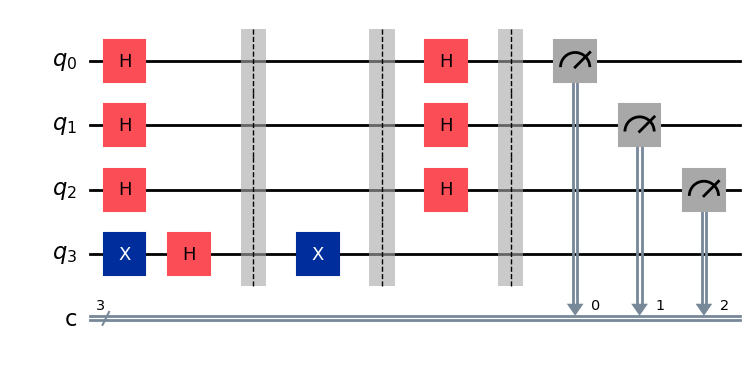

Resultados (Função Constante - Colapso em 000): {'000': 1000}


In [1]:
# Commit: [env] Prepara o ambiente de simulação e gráficos (Executar apenas uma vez)
!pip install -q qiskit qiskit-aer pylatexenc

# Importações principais
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Commit: [setup] Configura 3 qubits de entrada e 1 auxiliar, com 3 bits clássicos
qc_const = QuantumCircuit(4, 3)

# Commit: [feat] Prepara o qubit auxiliar no estado |-> e aplica superposição nas entradas
qc_const.x(3)
qc_const.h(3)
for q in range(3):
    qc_const.h(q)

qc_const.barrier()

# Commit: [logic] ORÁCULO CONSTANTE: Afeta apenas o auxiliar, f(x)=1
qc_const.x(3)

qc_const.barrier()

# Commit: [feat] Etapa de Interferência e Medição
for q in range(3):
    qc_const.h(q)

qc_const.barrier()
qc_const.measure([0, 1, 2], [0, 1, 2])

# Commit: [test] Executa a simulação sem ruído
simulador = AerSimulator()
resultados_const = simulador.run(qc_const, shots=1000).result().get_counts()

display(qc_const.draw('mpl'))
print(f"Resultados (Função Constante - Colapso em 000): {resultados_const}")

**# Bloco 2: Oráculo Balanceado**

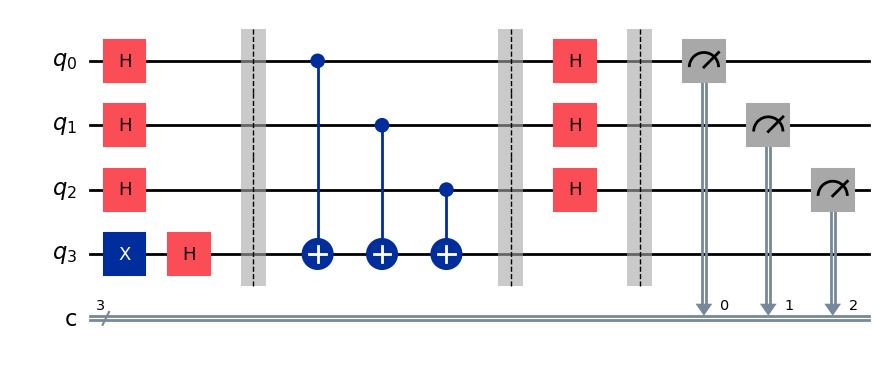

Resultados (Função Balanceada - Colapso em 111): {'111': 1000}


In [2]:
# Commit: [setup] Nova bancada para isolar a função balanceada
qc_bal = QuantumCircuit(4, 3)

# Commit: [feat] Preparação inicial (idêntica ao anterior)
qc_bal.x(3)
qc_bal.h(3)
for q in range(3):
    qc_bal.h(q)

qc_bal.barrier()

# Commit: [logic] ORÁCULO BALANCEADO: Conecta entradas ao auxiliar via CNOTs
qc_bal.cx(0, 3)
qc_bal.cx(1, 3)
qc_bal.cx(2, 3)

qc_bal.barrier()

# Commit: [feat] Etapa de Interferência e Medição
for q in range(3):
    qc_bal.h(q)

qc_bal.barrier()
qc_bal.measure([0, 1, 2], [0, 1, 2])

# Commit: [test] Executa a simulação sem ruído
resultados_bal = simulador.run(qc_bal, shots=1000).result().get_counts()

display(qc_bal.draw('mpl'))
print(f"Resultados (Função Balanceada - Colapso em 111): {resultados_bal}")